## General requirements & preparation

This timeseries script uses functions from atlite to generate weather timeseries for GENeSYS-MOD. It uses the ERA5 weather dataset, which is downloaded and transformed locally.
Please be aware that for the entire European dataset, a large amount of system memory is required (at least 24GB of RAM).


To use this script, you need to have the following packages installed:
- numpy
- matplotlib
- seaborn
- pandas / geopandas
- scikit-learn
- cartopy
- xarray
- atlite

In addition, in order to be able to load the ERA5 cutouts, you need an API key from https://cds.climate.copernicus.eu/user/register?destination=%2F%23!%2Fhome

To activate the API key, follow the instructions at https://cds.climate.copernicus.eu/api-how-to

For more information on how to run atlite, please refer to https://atlite.readthedocs.io/en/latest/

In [1]:
from functions import *

In [2]:
onshore_turbine = 'Vestas_V112_3MW'
offshore_turbine = 'Vestas_V164_7MW_offshore'
solar_panel = 'CSi'

# Region polygons to analyse: a geojson with a 'region' column. Results are produced
# per region in this file (not at country level).
geo_file = "geodata/iso_regions.geojson"
# Offshore boundary (EEZ). Offshore cells are clipped to this zone and assigned to the
# nearest region. Lower-48 US EEZ; Great Lakes are excluded (the EEZ is ocean only).
offshore_file = "geodata/eez_us.geojson"
# Bathymetry grid (z = metres, negative below sea level). Offshore cells are classified
# by water depth into shallow/transitional (fixed foundations) and deep (floating).
bathymetry_file = "geodata/bathymetry_us.nc"


timeframe = "2018"   # timeframe for the timeseries. format example: 2018 OR 2018-01 OR 2018-01-01
filename = "northamerica"   # filename for the downloaded raw data (cutout). this needs to be changed for every new run/year/region
output_dir = create_output_folder(timeframe)   # creates an output folder, if it does not exist yet

# admin is only used by the country/NUTS workflow; it is ignored in region-geojson mode
admin = 0

# Subset of region names from geo_file to keep. Leave the list empty to use all regions.
regions = []

# cutout cooridnates. Leave empty, if the cutout should be taken from a shapefile (with above specified regions)
cutout_north_west = []
cutout_south_east = []

The output folder already exists.


In [3]:
# PV slope/azimuth for utility-scale (ground-mounted) PV.
pv_slope = 36.7
pv_azimuth = 180

# Optimal tilt: if True, utility-scale PV uses a per-coordinate optimal fixed
# tilt (function of latitude) and equator-facing azimuth instead of the single
# pv_slope/pv_azimuth above. Cheap closed-form rule (no per-angle yield search).
pv_optimal_tilt = True

# Rooftop PV is installed differently (roof pitch / mixed orientations), so it
# keeps its own fixed slope/azimuth for the separate pv_rooftop timeseries.
rooftop_pv_slope = 25
rooftop_pv_azimuth = 180

# Usable-site thresholds: minimum developable share of a cutout cell for it
# to count as a usable location for the capacity-factor timeseries. Land is
# lenient (1%); rooftop is the built-up fraction (small everywhere), so it
# needs a higher bar to drop near-empty cells - raise if still too many.
usable_threshold = 0.01
usable_threshold_rooftop = 0.05

In [4]:
# Here, you need to define the horizontal and vertical distances (in degrees) between your coordinates
dx_step = 0.275
dy_step = 0.275

## Region Defitinition & Cutout preparation

In this block, you need to define your coordinates, either by using your own fixed coordinates (by defining custom bounds), or using the automatic .geojson mapping for the country of your choice.

Be aware that the first preparation of the cutout will take significant time!

In [5]:
# Pre-check the expected cutout size BEFORE downloading anything: grid cells,
# hourly time steps and total data points. Uses the same regions/geo_file/resolution
# as get_cutout below, so adjust dx/dy or the region selection if it is too large.
estimate_cutout_size(timeframe, regions=regions, geo_file=geo_file, dx=dx_step, dy=dy_step)

Expected cutout size:
  bounds (lon/lat) : [-125.71, -65.98] x [24.12, 50.38]
  grid             : 217 x 96 = 20,832 cells  (dx=0.275, dy=0.275)
  time steps       : 8,760 hourly  (2018)
  points/variable  : 182,488,320
  total points     : 2,007,371,520  (x11 variables)
  uncompressed     : ~8.03 GB float32 (on-disk .nc is far smaller, compressed)


{'nx': 217,
 'ny': 96,
 'n_cells': 20832,
 'n_time': 8760,
 'points_per_var': 182488320,
 'total_points': 2007371520,
 'raw_gb': 8.02948608}

In [6]:
cutout = get_cutout(filename, 
                    timeframe, 
                    regions=regions, 
                    geo_file=geo_file, 
                    dx=dx_step, 
                    dy=dy_step)

cutouts/northamerica_2018_27_27
Cutout already prepared with required variables; skipping prepare().


Plotting your cutout to ensure that everything is correct!

You can add zoom=True/False to zoom into your selection and use size to set the size of the graph if needed.

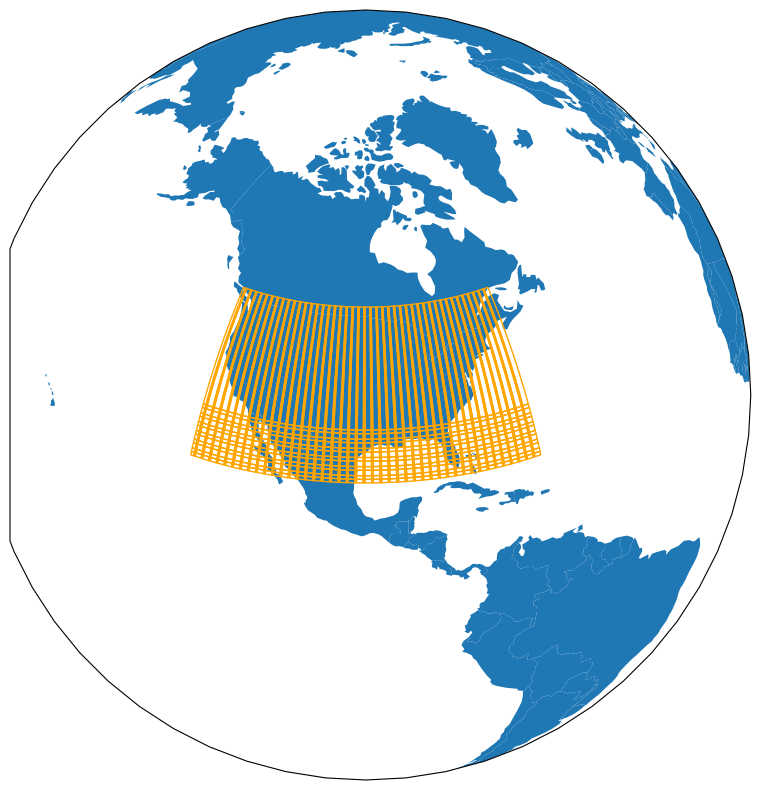

In [7]:
plot_country_map(cutout) # plot_country_map(cutout,zoom=False,size=8)

## General settings and functions

Always run these to create the relevant data entries.

In [8]:
coords_onshore, coords_offshore = get_coords(cutout, 
                                             regions, 
                                             geo_file, 
                                             admin=admin,
                                             offshore_file=offshore_file,
                                             bathymetry_file=bathymetry_file)

## Functions for timeseries generation

In [ ]:
pv_inf, pv_avg, pv_opt = pv_capacity_factors(cutout, 
                                             coords_onshore, 
                                             solar_panel,
                                             pv_slope=pv_slope,
                                             pv_azimuth=pv_azimuth, 
                                             optimal_tilt=pv_optimal_tilt,
                                             timeframe=timeframe, 
                                             filename=filename,
                                             write_raw_data=False,
                                             output_dir=output_dir)

In [ ]:
pv_tra = pv_capacity_factors(cutout, 
                             coords_onshore, 
                             solar_panel,
                             tracking= "horizontal",
                             pv_azimuth=0, #refers to oriantation of the axis in this case
                             timeframe=timeframe, 
                             filename=filename,
                             write_raw_data=False,
                             output_dir=output_dir)

In [ ]:
display(pv_inf.mean())
display(pv_avg.mean())
display(pv_opt.mean())

In [ ]:
display(pv_tra.mean())

In [ ]:
wind_onshore_inf, wind_onshore_avg, wind_onshore_opt = wind_onshore_capacity_factors(cutout, 
                                                                                     coords_onshore, 
                                                                                     onshore_turbine,  
                                                                                     timeframe=timeframe, 
                                                                                     filename=filename,
                                                                                     write_raw_data=False, # determines if you want to have the aggregated outputs per administrative region or the full dataset of each individual coordinate (default: False)
                                                                                     output_dir=output_dir)

In [ ]:
display(wind_onshore_inf.mean()) 
display(wind_onshore_avg.mean()) 
display(wind_onshore_opt.mean())

In [ ]:
wind_offshore_shallow, wind_offshore_transitional, wind_offshore_deep = wind_offshore_capacity_factors(cutout, 
                                                                                                       coords_offshore, 
                                                                                                       offshore_turbine, 
                                                                                                       timeframe=timeframe,
                                                                                                       filename=filename,
                                                                                                       write_raw_data=False, # determines if you want to have the aggregated outputs per administrative region or the full dataset of each individual coordinate (default: False)
                                                                                                       output_dir=output_dir)

In [ ]:
display(wind_offshore_shallow.mean())
display(wind_offshore_transitional.mean())
display(wind_offshore_deep.mean())

In [ ]:
df_heatpump_ground_cop, df_cooling, df_heating, df_heatpump_cop = temperature_timeseries(cutout,
                                                                                        coords_onshore,
                                                                                        timeframe=timeframe,
                                                                                        filename=filename,
                                                                                        write_raw_data=False, # determines if you want to have the aggregated outputs per administrative region or the full dataset of each individual coordinate (default: False)
                                                                                        output_dir=output_dir)

In [ ]:
display(df_heatpump_ground_cop.mean())
display(df_heatpump_cop.mean())
display(df_cooling.mean())
display(df_heating.mean())

# GIS-based renewable energy potentials

##### This part is still somewhat experimental. It uses functionality from the Atlite package to calculate available capcities for utility-scale PV, onshore wind, and rooftop PV installations.
##### It uses the information from the timeseries part to compute the shapefiles, the only thing that needs to be provided is the excluder zones (e.g. WDPA for protected areas). CORINE is provided for land cover in Europe, anything else would need to be separately downloaded.

In [9]:
# Region-agnostic: use the SAME region polygons as the timeseries (onshore),
# not the country/NUTS workflow. Returns region shapes + names.
shapes, regions_name_en = get_region_shapes(geo_file, regions)
#shapes, regions_name_en = get_region_shapes(geo_file, ['California'])

In [10]:
# --- Exclusion layers ------------------------------------------------------
# Builder functions are region-agnostic; only the paths/codes below are regional.
#
# NLCD source: this is the LC-Next *change-stratification* raster. Values 11-95 are
# the standard NLCD land-cover classes; 100-104 are change strata (100 Urban Gain,
# 101 Cropland Change, 102 Wetland/Water Flux, 103/104 disturbance). It has no
# embedded CRS, so we force EPSG:5070 (CONUS Albers).
NLCD     = "geodata/lcnext-1.0-stratum-map-Clipped.tif"
NLCD_CRS = "EPSG:5070"

# PAD-US File GDB. Most-inclusive managed-areas layer (strictest); GAP status 1 & 2
# = strict protection. Marine polygons are harmless onshore (no overlap).
PADUS       = "geodata/PADUS4_1Geodatabase.gdb"
PADUS_LAYER = "PADUS4_1Combined_Proclamation_Marine_Fee_Designation_Easement"

# STRICT land availability. Exclude water(11,12), developed(21-24), forest(41-43),
# wetlands(90,95), plus change strata that became unsuitable: urban gain(100),
# wetland/water flux(102), disturbance(103,104). Keep barren(31), shrub(52),
# herbaceous(71) and pasture(81). Cropland is now excluded.
# Cropland (82) and cropland-change (101) now excluded too: protect prime
# farmland. Drop them from this list to allow agrivoltaics / co-use.
nlcd_exclude = [11, 12, 21, 22, 23, 24, 41, 42, 43, 82, 90, 95, 100, 101, 102, 103, 104]

excluder = make_land_excluder(
    NLCD, nlcd_exclude, raster_crs=NLCD_CRS,
    protected_files=PADUS,
    protected_layer=PADUS_LAYER,
    protected_query="GAP_Sts in ['1', '2']",   # strict protection only (GAP status 1 & 2)
)

# Rooftop proxy: keep ONLY the genuinely built-up classes (22 low, 23 med,
# 24 high intensity developed). Excludes developed-OPEN-space (21: parks, golf
# courses, large-lot lawns - little actual roof) and urban-gain change (100),
# which otherwise inflate rooftop area above utility-scale land.
cities = make_rooftop_excluder(NLCD, [22, 23, 24], raster_crs=NLCD_CRS)

# --- Offshore exclusion (marine protected areas) ---------------------------
# Reuse the PAD-US GDB: the Marine layer holds marine protected areas. Passed to
# the offshore step so MPA cells are dropped (depth alone is not enough). Other
# sources (BOEM lease/shipping, NOAA MPA Inventory) can be added as a list.
OFFSHORE_EXCLUDE_FILES = PADUS
OFFSHORE_EXCLUDE_LAYER = "PADUS4_1Marine"
OFFSHORE_EXCLUDE_QUERY = None   # e.g. "GAP_Sts in ['1','2']" to keep only strict MPAs

In [11]:
pv_cap_per_sqkm = 100                   # MW
pv_percent_land_available = 0.03        # % of suitable area
wind_cap_per_sqkm = 27                  # MW
wind_percent_land_available = 0.03      # % of suitable area
rooftop_cap_per_sqkm = 100              # MW
rooftop_percent_area_available = 0.05   # installable share of built-up area

## Compute area availability (single pass, memory intensive)

This will calculate available surface areas for onshore, offshore, and rooftops using the excluders specified. Memory-intensive, since it calculates it all at once. See below for per-region loop version.

In [ ]:
AvailabilityMatrix = calculate_and_plot_available_area(admin,cutout,shapes,regions_name_en,excluder)

In [ ]:
AvailabilityMatrix_Rooftop = calculate_and_plot_available_rooftops(admin,cutout,shapes,regions_name_en,cities)

In [ ]:
output_df = calculate_capacity_potentials(cutout,coords_onshore,AvailabilityMatrix,AvailabilityMatrix_Rooftop,pv_cap_per_sqkm,pv_percent_land_available,wind_cap_per_sqkm,wind_percent_land_available,rooftop_cap_per_sqkm,rooftop_percent_area_available)

In [ ]:
# here is the resulting DataFrame containing all the potentials and areas that have been calculated
output_df

## Compute area availability (Memory-safe all-region run)

The cells above process every region at once, which rasterizes the land-cover map over the full extent and can exhaust RAM at 30 m. 
`calculate_potentials_per_region` processes one region at a time (bounded raster window), writes a per-region CSV plus a combined CSV, 
and returns one stitched availability map across all regions. Reuses the same `excluder`/`cities` defined above.

Processing region: California
Processing region: ERCOT
Processing region: MISO
Processing region: NewEngland
Processing region: NewYork
Processing region: PJM
Processing region: SERC
Processing region: SPP
Processing region: WECC
offshore exclusion: dropped 1330 of 1389 cells


,region,Area [km²],Suitable Area PV [km²],Suitable Area Wind [km²],Suitable Area Rooftops [km²],PV Capacity [GW],Rooftop Capacity [GW],Wind Capacity [GW]
0,California,4.135124e+05,3803.593330,3803.593330,677.769607,380.359333,67.776961,102.697020
1,ERCOT,6.899666e+05,11043.987925,11043.987925,857.515993,1104.398793,85.751599,298.187674
2,MISO,1.465690e+06,5102.032075,5102.032075,2561.319109,510.203207,256.131911,137.754866
3,NewEngland,1.695430e+05,247.911177,247.911177,337.874647,24.791118,33.787465,6.693602
4,NewYork,1.200549e+05,517.877331,517.877331,313.555686,51.787733,31.355569,13.982688
5,PJM,6.845462e+05,2806.473602,2806.473602,1682.469878,280.647360,168.246988,75.774787
6,SERC,6.273690e+05,2103.766483,2103.766483,1273.451890,210.376648,127.345189,56.801695
7,SPP,9.690645e+05,11341.469481,11341.469481,663.712922,1134.146948,66.371292,306.219676
8,WECC,2.666227e+06,41157.348458,41157.348458,1322.299523,4115.734846,132.229952,1111.248408


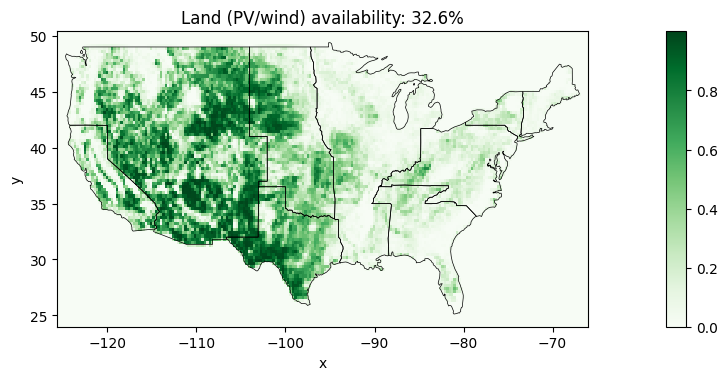

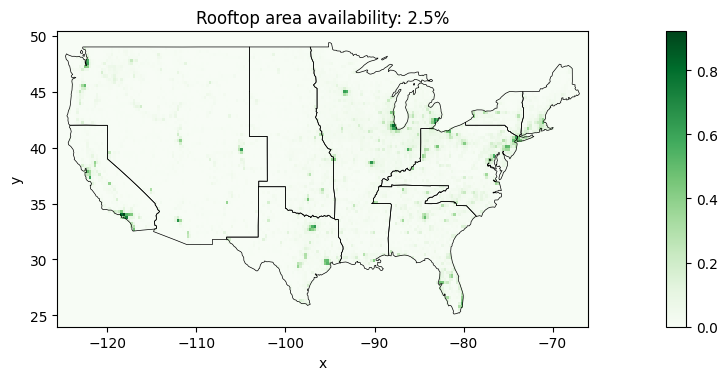

In [12]:
# Memory-safe: process every region one at a time. Saves per-region + combined
# CSVs, returns one stitched availability map AND the usable coords (all regions)
# for the usable-site timeseries below: land (PV/onshore wind), rooftop, offshore.
# Offshore cells are filtered by depth AND marine protected areas. regions=[] = all.
combined_potentials, stitched_land, stitched_rooftop, coords_onshore_usable, coords_rooftop_usable, coords_offshore_usable = calculate_potentials_per_region(
    cutout, geo_file, coords_onshore,
    excluder=excluder, cities=cities,
    regions=regions,
    coords_offshore=coords_offshore,
    usable_threshold=usable_threshold, usable_threshold_rooftop=usable_threshold_rooftop,
    offshore_exclude_files=OFFSHORE_EXCLUDE_FILES,
    offshore_exclude_layer=OFFSHORE_EXCLUDE_LAYER,
    offshore_exclude_query=OFFSHORE_EXCLUDE_QUERY,
    pv_cap_per_sqkm=pv_cap_per_sqkm, pv_percent_land_available=pv_percent_land_available,
    wind_cap_per_sqkm=wind_cap_per_sqkm, wind_percent_land_available=wind_percent_land_available,
    rooftop_cap_per_sqkm=rooftop_cap_per_sqkm, rooftop_percent_area_available=rooftop_percent_area_available,
    output_dir=output_dir, filename=filename,
)
combined_potentials

### Offshore wind potential

Reuses the EEZ-clipped, depth-classified offshore cells from `get_coords` (so only actual offshore zones are counted). Capacity density and available share can be set per depth class (shallow/transitional = fixed-bottom, deep = floating).

In [13]:
# Offshore wind potential per region and depth class. Uses coords_offshore from
# the timeseries step (EEZ + depth). Densities/availability can be a scalar or a
# dict keyed by depth class. Floating (deep) gets a lower available share here.
offshore_cap_per_sqkm = 5            # MW/km2
offshore_percent_available = {"shallow": 0.10, "transitional": 0.10, "deep": 0.05}

offshore_df = calculate_offshore_potentials(
    cutout, coords_offshore,
    offshore_cap_per_sqkm=offshore_cap_per_sqkm,
    offshore_percent_available=offshore_percent_available,
)
offshore_df

,region,depth_class,Area [km²],Suitable Area Offshore [km²],Offshore Wind Capacity [GW]
0,California,shallow,3599.070170,359.907017,1.799535
1,California,transitional,3697.896375,369.789638,1.848948
2,California,deep,71995.184298,3599.759215,17.998796
3,ERCOT,shallow,27884.102201,2788.410220,13.942051
4,ERCOT,transitional,20658.114368,2065.811437,10.329057
5,ERCOT,deep,37303.681477,1865.184074,9.325920
6,MISO,shallow,44786.093380,4478.609338,22.393047
7,MISO,transitional,16367.032522,1636.703252,8.183516
8,MISO,deep,50236.827645,2511.841382,12.559207
9,NewEngland,shallow,17440.250689,1744.025069,8.720125


### Capacity-factor timeseries on usable sites only

Restrict the RES timeseries to cells that survive the exclusion layers. 
`usable_onshore_coords` keeps cutout cells whose availability > threshold (from the 
availability matrix); feed those into the normal PV / onshore-wind functions, which 
still split into opt/avg/inf. `usable_offshore_coords` keeps buildable offshore cells 
(depth within limits) for the offshore-wind timeseries.

In [14]:
# Usable onshore sites across ALL regions come from the memory-safe loop above
# (coords_onshore_usable). For a quick single-region test instead, use:
#   coords_onshore_usable = usable_onshore_coords(AvailabilityMatrix, coords_onshore)
print(f"usable onshore cells: {len(coords_onshore_usable)} of {len(coords_onshore)}")
print(f"usable rooftop cells: {len(coords_rooftop_usable)} of {len(coords_onshore)}")

# Utility-scale PV on usable land (per-cell optimal tilt if pv_optimal_tilt):
pv_inf_u, pv_avg_u, pv_opt_u = pv_capacity_factors(cutout, coords_onshore_usable, solar_panel,
                                                   pv_slope=pv_slope, pv_azimuth=pv_azimuth,
                                                   optimal_tilt=pv_optimal_tilt,
                                                   timeframe=timeframe, filename=filename+"_usable",
                                                   write_raw_data=False, output_dir=output_dir)

# Rooftop PV: separate category, only rooftop-available cells, own fixed slope/azimuth
# (roofs dictate orientation, so no optimal-tilt here). Label "pv_rooftop".
pv_roof_inf, pv_roof_avg, pv_roof_opt = pv_capacity_factors(cutout, coords_rooftop_usable, solar_panel,
                                                            pv_slope=rooftop_pv_slope, pv_azimuth=rooftop_pv_azimuth,
                                                            tech_label="pv_rooftop",
                                                            timeframe=timeframe, filename=filename+"_usable",
                                                            write_raw_data=False, output_dir=output_dir)

# Onshore wind capacity factors on usable land:
wind_inf_u, wind_avg_u, wind_opt_u = wind_onshore_capacity_factors(cutout, coords_onshore_usable, onshore_turbine,
                                                                   timeframe=timeframe, filename=filename+"_usable",
                                                                   write_raw_data=False, output_dir=output_dir)

usable onshore cells: 10099 of 10841
usable rooftop cells: 1139 of 10841


usable offshore cells: 59 of 2727


<Axes: title={'center': 'Usable offshore cells by depth_class'}>

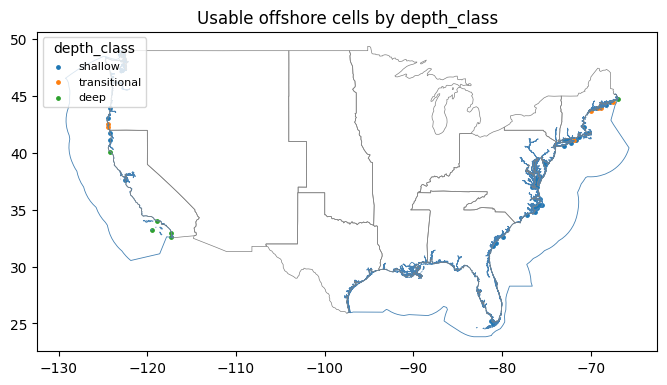

In [15]:
# Usable offshore sites across ALL regions come from the loop above
# (coords_offshore_usable), already filtered by depth AND marine protected areas.
if coords_offshore_usable is None:
    coords_offshore_usable = usable_offshore_coords(coords_offshore,
        exclude_files=OFFSHORE_EXCLUDE_FILES, exclude_layer=OFFSHORE_EXCLUDE_LAYER,
        exclude_query=OFFSHORE_EXCLUDE_QUERY)
print(f"usable offshore cells: {len(coords_offshore_usable)} of {len(coords_offshore)}")

# Offshore wind capacity factors on usable sites only (shallow/transitional/deep):
wind_off_shallow_u, wind_off_trans_u, wind_off_deep_u = wind_offshore_capacity_factors(
    cutout, coords_offshore_usable, offshore_turbine,
    timeframe=timeframe, filename=filename+"_usable",
    write_raw_data=False, output_dir=output_dir)

# Map of the usable offshore cells, coloured by depth class:
plot_offshore_map(coords_offshore_usable, shapes=shapes, offshore_file=offshore_file, color_by="depth_class")